# The Revenue Forecast Everyone Believed - companion notebook

This notebook is the **Vibe Analytics** reasoning layer for the Fabric IQ Plan demo. It carries the
four **CRIT** prompts inline and reproduces every number in [README.md](./README.md).

It runs **fully offline** against the CSVs in [`data/`](./data), so you can rehearse the whole talk
track before building anything in Fabric. Once you've built and written back the plan
(see [setup-plan.md](./setup-plan.md)), the last section shows how to point the same analysis at the
Plan **writeback SQL database** instead.

**How to use it in VS Code:** read each `> Context / Role / Interview / Task` prompt out loud (or
paste it into Copilot Chat), then run the cell beneath it to see the evidence. The prompts are
generic - they don't depend on any Fabric-specific assistant.

In [1]:
import os
import pandas as pd

DATA = os.path.join(os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else '.', 'data')

actuals = pd.read_csv(os.path.join(DATA, 'cascadia.sales_actuals.csv'), parse_dates=['DateKey'])
product = pd.read_csv(os.path.join(DATA, 'cascadia.dim_product.csv'))
region = pd.read_csv(os.path.join(DATA, 'cascadia.dim_region.csv'))
channel = pd.read_csv(os.path.join(DATA, 'cascadia.dim_channel.csv'))

df = actuals.merge(product[['ProductKey', 'Category', 'Brand', 'LifecycleStatus']], on='ProductKey')
df['Month'] = df['DateKey'].dt.month
df['Half'] = df['Month'].apply(lambda m: 'H1' if m <= 6 else 'H2')

print(f'Fact rows: {len(df):,}')
print(f'FY2025 total Net Revenue: ${df.NetRevenue.sum():,.0f}')
df.head()

Fact rows: 4,200
FY2025 total Net Revenue: $153,200,919


,DateKey,ProductKey,RegionKey,ChannelKey,UnitsSold,NetRevenue,COGS,GrossMargin,TradeSpend,Category,Brand,LifecycleStatus,Month,Half
0,2025-01-01,COLA-CHERRY,Midwest,Club,2502,30023.17,16512.74,13510.43,4203.24,Cola / CSD,ClassicCola,Declining,1,H1
1,2025-01-01,COLA-CHERRY,Midwest,Convenience,2880,34558.63,19007.25,15551.38,4838.21,Cola / CSD,ClassicCola,Declining,1,H1
2,2025-01-01,COLA-CHERRY,Midwest,Ecommerce,1227,14728.18,8100.50,6627.68,2061.95,Cola / CSD,ClassicCola,Declining,1,H1
3,2025-01-01,COLA-CHERRY,Midwest,Foodservice,1748,20971.22,11534.17,9437.05,2935.97,Cola / CSD,ClassicCola,Declining,1,H1
4,2025-01-01,COLA-CHERRY,Midwest,Grocery,4150,49801.78,27390.98,22410.80,6972.25,Cola / CSD,ClassicCola,Declining,1,H1


## Prompt 1 - Generate competing hypotheses (do NOT accept +8%)

```text
> Context:
I work in FP&A at Cascadia Beverages, a ~$153M CPG beverage company. For our FY2026 annual plan,
Sales proposes growing every SKU, region, and channel by a uniform +8%. That total (~$165M) clears
the board target, so there is pressure to just approve it. I have our FY2025 monthly actuals in a
table called sales_actuals (NetRevenue, COGS, GrossMargin, TradeSpend, UnitsSold) with product,
region, channel, and date dimensions. Assume the actuals are roughly accurate but VERIFY anything
before relying on it.

> Role:
You are a CPG financial planning analyst with 15 years of enterprise planning experience. You are
deeply skeptical of flat, top-down growth rates. You know a uniform percentage hides mix shifts,
dying products, and one-time revenue that will not recur. You are new to Cascadia's data, so start
with exploratory data analysis before you trust anything.

> Interview:
I am the FP&A lead. Do NOT tell me to approve the +8% plan. Instead, give me FIVE competing reasons
the uniform +8% plan is likely wrong, ranked by how testable they are with the data I have. For
each, tell me exactly which columns/dimensions and which query would confirm or REFUTE it. Then ask
me clarifying questions. I want you to actively try to prove the "+8% everywhere" story WRONG.

> Task:
Go.
```

The cell below is the exploratory data analysis (EDA) the analyst would run first.

In [2]:
total = df.NetRevenue.sum()
print(f'FY2025 Net Revenue:      ${total:,.0f}')
print(f'Naive uniform +8% plan:  ${total * 1.08:,.0f}  (this is the board-target number)')

print('\nBy category:')
print(df.groupby('Category').NetRevenue.sum().sort_values(ascending=False).map('${:,.0f}'.format))

print('\nBy region:')
print(df.groupby('RegionKey').NetRevenue.sum().sort_values(ascending=False).map('${:,.0f}'.format))

print('\nLifecycle status is sitting right there in the product master:')
print(product.groupby('LifecycleStatus').SKU.count())

FY2025 Net Revenue:      $153,200,919
Naive uniform +8% plan:  $165,456,992  (this is the board-target number)

By category:
Category
Cola / CSD         $50,124,448
Juice              $32,988,389
Still Water        $28,043,574
Sparkling Water    $24,030,150
Energy             $18,014,358
Name: NetRevenue, dtype: object

By region:
RegionKey
West         $39,001,749
Midwest      $33,163,002
South        $33,032,290
Northeast    $27,003,618
Mountain     $21,000,260
Name: NetRevenue, dtype: object

Lifecycle status is sitting right there in the product master:
LifecycleStatus
Declining    4
Growth       5
Mature       5
Name: SKU, dtype: int64


## Prompt 2 - Kill the flat-rate assumption with the mix

```text
> Task:
Let's test the "one growth rate fits all" assumption first. Aggregate FY2025 NetRevenue by Category
and compute each category's within-year trajectory (compare the first quarter to the last quarter,
annualized). If a flat +8% were reasonable, every category would be trending similarly. Show me the
categories side by side, tell me honestly which ones a +8% plan OVER-plans and which it UNDER-plans,
and quantify the dollar error per category if we grow each at its own trajectory instead of +8%.
Don't soften it.
```

The data shows the *direction* (Q4 run-rate vs Q1). The forward category growth rates below come
from that trajectory plus the lifecycle status and external category/market data - exactly the kind
of driver a Plan **cube** would use instead of a flat percentage.

In [3]:
# Evidence from the data: is each category trending up or down within the year?
q = df.assign(Q=((df.Month - 1) // 3 + 1))
qtr = q.groupby(['Category', 'Q']).NetRevenue.sum().unstack('Q')
trend = pd.DataFrame({
    'Q1': qtr[1],
    'Q4': qtr[4],
    'Q4 vs Q1': (qtr[4] / qtr[1] - 1),
})
print('Within-year trajectory (Q4 vs Q1) - the direction the flat +8% ignores:')
print(trend.assign(**{'Q4 vs Q1': trend['Q4 vs Q1'].map('{:+.1%}'.format)}).to_string())

# Forward planning growth by category (driver): informed by trajectory + lifecycle + market data
GROWTH = {
    'Sparkling Water': 0.20,
    'Energy': 0.15,
    'Juice': 0.03,
    'Still Water': 0.01,
    'Cola / CSD': -0.06,
}

cat = df.groupby('Category').NetRevenue.sum().rename('FY2025')
compare = pd.DataFrame({'FY2025': cat})
compare['Naive +8%'] = compare['FY2025'] * 1.08
compare['Driver'] = compare.index.map(lambda c: cat[c] * (1 + GROWTH[c]))
compare['Error (+8% - Driver)'] = compare['Naive +8%'] - compare['Driver']
print('\nNaive +8% vs driver-based, per category:')
print(compare.applymap(lambda v: f'${v:,.0f}').to_string())
print(f"\nTotal naive +8%:   ${compare['Naive +8%'].sum():,.0f}")
print(f"Total driver:      ${compare['Driver'].sum():,.0f}")
print(f"Mix over-plan:     ${compare['Error (+8% - Driver)'].sum():,.0f}")

Within-year trajectory (Q4 vs Q1) - the direction the flat +8% ignores:
                          Q1           Q4 Q4 vs Q1
Category                                          
Cola / CSD       11795417.97  10768856.37    -8.7%
Energy            4152640.10   4651956.44   +12.0%
Juice             7316162.94   7656195.99    +4.6%
Sparkling Water   4936149.76   5966117.65   +20.9%
Still Water       6427487.16   6246171.49    -2.8%

Naive +8% vs driver-based, per category:
                      FY2025    Naive +8%       Driver Error (+8% - Driver)
Category                                                                   
Cola / CSD       $50,124,448  $54,134,404  $47,116,981           $7,017,423
Energy           $18,014,358  $19,455,507  $20,716,512          $-1,261,005
Juice            $32,988,389  $35,627,460  $33,978,041           $1,649,419
Sparkling Water  $24,030,150  $25,952,562  $28,836,180          $-2,883,618
Still Water      $28,043,574  $30,287,060  $28,324,010           $1,963,0

## Prompt 3 - Follow the one region that won't behave

```text
> Task:
The mix story holds, but I want to check regions too. Plot FY2025 NetRevenue by month for each
Region, and separately for Region x Channel. If any series has a sudden step-change (not a smooth
trend), isolate exactly which Region and Channel and which month it breaks. Then tell me: what could
make a single Region x Channel fall off a cliff in one month while everything else keeps trending?
Frame it as a hypothesis I can go verify outside this dataset.
```

Sharpest single-month drop: Midwest x Club at month 9 (-47%)

Midwest x Club by month:
Month
1     $836,717
2     $831,228
3     $867,841
4     $889,088
5     $931,824
6     $959,468
7     $974,666
8     $976,769
9     $516,035
10    $492,090
11    $468,702
12    $460,646


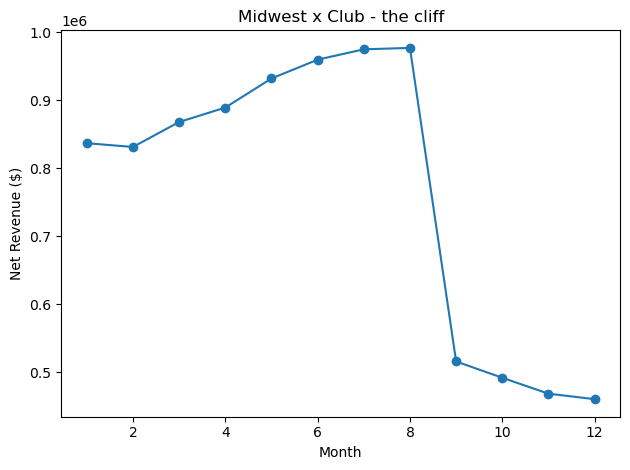

In [4]:
# Region x Channel by month, then flag the biggest single month-over-month drop.
rc = df.groupby(['RegionKey', 'ChannelKey', 'Month']).NetRevenue.sum().reset_index()
rc['mom'] = rc.groupby(['RegionKey', 'ChannelKey']).NetRevenue.pct_change()
worst = rc.loc[rc['mom'].idxmin()]
print(f"Sharpest single-month drop: {worst.RegionKey} x {worst.ChannelKey} "
      f"at month {int(worst.Month)} ({worst['mom']:+.0%})\n")

cliff = (df[(df.RegionKey == worst.RegionKey) & (df.ChannelKey == worst.ChannelKey)]
         .groupby('Month').NetRevenue.sum())
print(f'{worst.RegionKey} x {worst.ChannelKey} by month:')
print(cliff.map('${:,.0f}'.format).to_string())

try:
    import matplotlib.pyplot as plt
    ax = cliff.plot(marker='o', title=f'{worst.RegionKey} x {worst.ChannelKey} - the cliff')
    ax.set_ylabel('Net Revenue ($)'); ax.set_xlabel('Month')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'(plot skipped: {e})')

## Prompt 4 - Bring in the contract, then re-plan and quantify

```text
> Task:
The Midwest x Club channel collapses in September. The cause isn't in the semantic model - it's in
distributor_contracts.xlsx: MegaMart Wholesale terminated effective 2025-09-01, ~$400K/month, and
~$3.2M of its revenue is already in the FY2025 base (Jan-Aug). Load that file. Then build TWO
corrected FY2026 plans and compare all three:
  (a) Base: uniform +8% on FY2025 actuals
  (b) Driver-Based: each category grown at its own trajectory
  (c) Distributor-Adjusted: driver-based, PLUS remove the MegaMart phantom base before growing
For each, give me total NetRevenue and the delta vs Base. Quantify: how much of the +8% plan is
revenue that cannot recur, how much is over-planned on the declining cola line, and how the
trade-promo dollars should move. Finish with a prescriptive recommendation I can take to the board.
```

In [5]:
# The smoking gun - tribal knowledge that was never in the semantic model.
contracts = pd.read_excel(os.path.join(DATA, 'distributor_contracts.xlsx'), sheet_name='Contracts')
mm = contracts[contracts.Status == 'TERMINATED'].iloc[0]
print('Distributor contract on file:')
print(f"  {mm.DistributorName} - {mm.Status} eff {mm.EffectiveEndDate}")
print(f"  Carried: {mm.SKUsCarried}")
print(f"  Note: {mm.Notes}\n")

# Phantom base = $400K/month x 8 months already booked in FY2025, split across the SKUs it carried.
phantom_total = mm.MonthlyRevenue * 8
mm_skus = [s.strip() for s in mm.SKUsCarried.split(',')]
phantom_per_sku = phantom_total / len(mm_skus)
sku_cat = product.set_index('SKU').Category.to_dict()
phantom_grown = sum(phantom_per_sku * (1 + GROWTH[sku_cat[s]]) for s in mm_skus)

base = total * 1.08
driver = compare['Driver'].sum()
dist_adj = driver - phantom_grown

plans = pd.DataFrame({
    'FY2026 Net Revenue': [base, driver, dist_adj],
    'vs Base': [0, driver - base, dist_adj - base],
}, index=['Base (+8% uniform)', 'Driver-Based', 'Distributor-Adjusted'])
print('Three plans:')
print(plans.applymap(lambda v: f'${v:,.0f}').to_string())

cola_overplan = compare.loc['Cola / CSD', 'Error (+8% - Driver)']
print('\n--- The board-ready quantification -------------------------------------')
print(f'Revenue that CANNOT recur (MegaMart, grown into +8% plan): ${phantom_grown:,.0f}')
print(f'Over-planned on the declining cola line by +8%:            ${cola_overplan:,.0f}')
print(f'Total the +8% plan overstates achievable FY2026 revenue:   ${base - dist_adj:,.0f}')

Distributor contract on file:
  MegaMart Wholesale (Midwest) - TERMINATED eff 2025-09-01
  Carried: COLA-REG, STL-1L, COLA-DIET
  Note: MegaMart consolidated to a competitor's DSD network. Final shipment Aug 2025. ~$3.2M already booked in FY2025 (Jan-Aug) will NOT recur. Do not carry this base into FY2026. Finance was not looped in before the annual plan was drafted.

Three plans:
                     FY2026 Net Revenue      vs Base
Base (+8% uniform)         $165,456,992           $0
Driver-Based               $158,971,723  $-6,485,269
Distributor-Adjusted       $155,889,056  $-9,567,936

--- The board-ready quantification -------------------------------------
Revenue that CANNOT recur (MegaMart, grown into +8% plan): $3,082,667
Over-planned on the declining cola line by +8%:            $7,017,423
Total the +8% plan overstates achievable FY2026 revenue:   $9,567,936


In [6]:
# Where the trade-promo dollars are pointed today vs where the driver says growth is.
trade = df.groupby('Category').agg(NetRevenue=('NetRevenue', 'sum'),
                                   TradeSpend=('TradeSpend', 'sum'))
trade['Trade %'] = trade.TradeSpend / trade.NetRevenue
trade['Fwd growth'] = trade.index.map(GROWTH)
trade = trade.sort_values('Fwd growth', ascending=False)
print('Trade spend follows last year\'s revenue, not next year\'s growth:')
print(trade.assign(
    NetRevenue=trade.NetRevenue.map('${:,.0f}'.format),
    TradeSpend=trade.TradeSpend.map('${:,.0f}'.format),
    **{'Trade %': trade['Trade %'].map('{:.1%}'.format),
       'Fwd growth': trade['Fwd growth'].map('{:+.0%}'.format)}
).to_string())
print('\nRecommendation: do not approve the flat +8%. Adopt the Distributor-Adjusted plan,')
print('and shift trade-promo dollars OUT of Cola / CSD (declining, over-funded) INTO')
print('Sparkling Water and Energy (growing, under-funded).')

Trade spend follows last year's revenue, not next year's growth:
                  NetRevenue  TradeSpend Trade % Fwd growth
Category                                                   
Sparkling Water  $24,030,150  $1,922,412    8.0%       +20%
Energy           $18,014,358  $1,981,579   11.0%       +15%
Juice            $32,988,389  $2,968,955    9.0%        +3%
Still Water      $28,043,574  $1,682,614    6.0%        +1%
Cola / CSD       $50,124,448  $7,017,422   14.0%        -6%

Recommendation: do not approve the flat +8%. Adopt the Distributor-Adjusted plan,
and shift trade-promo dollars OUT of Cola / CSD (declining, over-funded) INTO
Sparkling Water and Energy (growing, under-funded).


## Optional - reason over the Plan writeback SQL database

Once you've built the plan and run **Writeback All** (see [setup-plan.md](./setup-plan.md) Step 8),
the three committed scenarios live in the Fabric **SQL database** that was auto-created with the
Plan item. Point the same analysis at that database instead of the CSVs by connecting to its
**T-SQL endpoint**.

The cell below is a template - fill in your server/database and adjust the scenario table/view name
to match your plan. It is not executed offline.

```python
import pyodbc, pandas as pd

# Copy the SQL connection string from the SQL database item in your Fabric workspace.
conn = pyodbc.connect(
    'Driver={ODBC Driver 18 for SQL Server};'
    'Server=<your-fabric-sql-endpoint>,1433;'
    'Database=<Cascadia FY2026 Plan SQL DB>;'
    'Authentication=ActiveDirectoryInteractive;'
    'Encrypt=yes;'
)

committed = pd.read_sql('SELECT Scenario, Category, SUM(PlanNetRevenue) AS NetRevenue '
                        'FROM plan_writeback GROUP BY Scenario, Category', conn)
print(committed.pivot(index='Category', columns='Scenario', values='NetRevenue'))
```

From here the same CRIT prompts apply - the LLM now reasons over the **committed plan** rather than
the raw actuals, so you can validate that what was approved in Plan matches the story.